# Car Insurance Claim Data Analysis

**Aviva** offers multiple products and services, spanning over pensions, insurnace and investments, with one of their main insurance products is Car insurance (Aviva, 2018). Within this file, a car insurance claim database will be uploaded and analysed to help shape Aviva's car insurance claim prediction model.


---



The code will be focused around this research question:
***"If a vehicle has poor saftey features, is the policyholder more likely to make a claim?"***


---



This notebook will:

1. Upload the relevant dataset
2. Profile the data
3. Clean the data- drop columns that are not needed and manage duplicates/null values
4. Produce 3 visualisations to show comparisons of values
5. Utilise a machine learning model and analyse it to see if there is a relationship between safety features in a car and the liklihood of a claim
6. Reflect on the outcome against the research question




# Setup

Before running the program the following install and import scripts will need to be ran. They are all required and used within the following scripts to help answer the research question- aiming to help visualise the data, clean it, visualise data for comparisons and then utilise the cleansed data in a machine learning model.


In [1]:
# Only run this once
!pip -q install skimpy -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.2.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incom

In [2]:
# Run this everytime

# Imports required for data cleaning and profiling
import pandas as pd
from skimpy import skim

# Imports required for visualisations
import seaborn as sns
import matplotlib.pyplot as plt

# Imports required for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

## Upload Dataset

The database will need to be in a local file for the following upload to work.

Once the dataset is uploaded, a confirmation messaage is displayed to the user.

**Please note** without the below code running successfully, the other code blocks will not work.

In [3]:
# Please check that the database is in the correct file path
df = pd.read_csv("kaggleClaimData.csv")

print('Loaded database!')


Loaded database!


# Preprocessing

As Çetin and Yıldız (2022) explain it is essential to preprocess data before data analysis. The purpose of preprocessing is to remove inconsistencies within the dataset which may skew the results and conclusion against the research question. These inconsistencies include incomplete, erroneous or unwanted data.

Below the data will initally be profiled, to spot any unwanted data but also understand the shape of the data, to then effectively clean it, preparing it for data analysis.

## Pandas Data Profiling

Below the data will be displayed to visualise what the data currently looks like before data cleansing using the pandas library's methods. Gordon et al., (2022) found, from research, that Pandas is one of the best data profiling methods utilised due to providing all essential functions.

In [4]:
print("First five rows:")
df.head()

First five rows:


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [5]:
print("Last five rows:")
df.tail()

Last five rows:


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
58587,ID58588,0.355089,0.13,0.644231,C8,8794,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0
58588,ID58589,1.199642,0.02,0.519231,C14,7788,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
58589,ID58590,1.162273,0.05,0.451923,C5,34738,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
58590,ID58591,1.236307,0.14,0.557692,C8,8794,1,B2,M6,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
58591,ID58592,0.124429,0.02,0.442308,C8,8794,3,C2,M4,Diesel,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0


In [6]:
print('Random data sample:')
df.sample(5)

Random data sample:


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
30323,ID30324,0.200502,0.06,0.615385,C19,27742,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
21876,ID21877,1.173084,0.10,0.596154,C2,27003,5,C1,M9,Diesel,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,1
54651,ID54652,0.110543,0.14,0.307692,C8,8794,1,B2,M6,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
132,ID00133,0.370911,0.09,0.480769,C10,73430,3,C2,M4,Diesel,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
53245,ID53246,0.216506,0.02,0.336538,C5,34738,1,B2,M6,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0


In [7]:
print("Dataset dimensions: ", df.shape)

Dataset dimensions:  (58592, 44)


In [8]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  str    
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  str    
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  str    
 8   model                             58592 non-null  str    
 9   fuel_type                         58592 non-null  str    
 10  max_torque                        58592 non-null  str    
 11  max_power                         58592 non-null  str    

From the basic methods of profiling, the database has 58592 rows with 44 columns. These columns accumulate three data types- string (text), integers (whole numbers), and floats (decimal numbers). It has also highlighted, that there are no null values.

Although this method of profiling is easy and provides the foundation of understanding required for cleaning, there are other, ways to visualise profiling of data, which may have better usability...

## Data profiling using skimpy

Skimpy is a library used to help visualise a summarised table of statistics for a database. The typical method of producing a summary is through using pandas, however, Skimpy provides the same functionalities but in a more visually appealing method. Manovich (2025) explains that if data is visualised effectively, readers can decipher patterns quicker.

In [9]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 58592  │ │ string      │ 28    │                                                          │
│ │ Number of columns │ 44     │ │ int64       │ 12    │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 4     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column              ┃ NA ┃ NA % ┃ mean    ┃ sd      ┃ p0       ┃ p25    ┃ p50    ┃ p75    ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │    policy_tenure    │  0 │    0 │  0.6112 │  0.4142 │ 0.002735 │ 0.2102 │ 0.5738 │  1.039 │ 1.397 │ █▅▄▃▇▃ │  │
│ │     age_of_car      │  0 │    0 │ 0.06942 │ 0.05672 │        0 │   0.02 │   0.06 │   0.11 │     1 │   █    │  │
│ │ age_of_policyholder │  0 │    0 │  0.4694 │  0.1229 │   0.2885 │ 0.3654 │ 0.4519 │ 0.5481 │     1 │  █▇▄▂  │  │
│ │ population_density  │  0 │    0 │   18830 │   17660 │      290 │   6112 │   8794 │  27000 │ 73430 │ █▁▄  ▁ │  │
│ │        make         │  0 │    0 │   1.764 │   1.137 │        1 │      1 │      1 │      3 │     5 │  █  ▃  │  │
│ │       airbags       │  0 │    0 │   3.137 │   1.833 │        1 │      2 │      2 │      6 │     6 │  █   ▃ │  │
│ │    displacement     │  0 │    0 │    1162 │   266.3 │      796 │    796 │   1197 │   1493 │  1498 │ ▆▃ █ ▇ │  │
│ │      cylinder       │  0 │    0 │   3.627 │  0.4836 │        3 │      3 │      4 │      4 │     4 │ ▅    █ │  │
│ │      gear_box       │  0 │    0 │   5.245 │  0.4304 │        5 │      5 │      5 │      5 │     6 │ █    ▃ │  │
│ │   turning_radius    │  0 │    0 │   4.853 │  0.2281 │      4.5 │    4.6 │    4.8 │      5 │   5.2 │ █▂▇▃▂▇ │  │
│ │       length        │  0 │    0 │    3850 │   311.5 │     3445 │   3445 │   3845 │   3995 │  4300 │ ▇▃█▄ ▇ │  │
│ │        width        │  0 │    0 │    1672 │   112.1 │     1475 │   1515 │   1735 │   1755 │  1811 │ ▇▁▂▁█▇ │  │
│ │       height        │  0 │    0 │    1553 │   79.62 │     1475 │   1475 │   1530 │   1635 │  1825 │  █ ▃▁  │  │
│ │    gross_weight     │  0 │    0 │    1385 │   212.4 │     1051 │   1185 │   1335 │   1510 │  1720 │ ▂▆█▂▁▆ │  │
│ │     ncap_rating     │  0 │    0 │    1.76 │    1.39 │        0 │      0 │      2 │      3 │     5 │ ▇ █▅▁▁ │  │
│ │      is_claim       │  0 │    0 │ 0.06397 │  0.2447 │        0 │      0 │      0 │      0 │     1 │ █    ▁ │  │
│ └─────────────────────┴────┴──────┴─────────┴─────────┴──────────┴────────┴────────┴────────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━

The skimpy profiling has also displayed that there are no null values, three data types, and the number of rows and columns, but in tables, aiding readability. It has also displayed data about the columns, separating this analysis into two tables- numbers and strings. These tables describe the data from means for numbers and shortest/longest words for strings. For numbers, it displays histograms to visualise the distribution of data, and providing an early opportunity to observe anomalies.

## Data cleansing

Data cleansing ensures that data is accurate to ensure that the machine learning model is accurate and produces reliable results. If there are missing values, it can cause biased results and be less generalisable (Albahra et al., 2023).  Maharana et al., (2022) and Yasodha (2025) concluded that the possibility of "noisy" data is high because data collection methods have the risk of human errors and technical limitations, accentuating that null/missing values are inevitable.

Before dropping columns that are unecessary, null and duplicate values will be dealt with first as once columns are dropped, duplicate value checks may show false positives- it may show duplicates, when in fact the original full row of data is not a duplicate.


### Remove Duplicated Data

Removing duplicated data is a prerequisite to further data cleansing. Nauman and Herschel (2022) state that duplicated data is found within most databases with multiple entries reflecting one instance. These duplicates have detrimental effects on data analysis and machine learning model predictions, affecting overall accuracy, so it is essential they are removed.

In [10]:
print("Number of duplicated rows before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Number of duplicated rows after:", df.duplicated().sum())

Number of duplicated rows before: 0
Number of duplicated rows after: 0


The output of the code above has indicated that there was no duplicate values. This is very uncommon, as previosuly mentioned, human error and techincal issues relating to collection methods commonly cause these instances to occur. However, the code still will remove duplicates to show how they would be dealt with- removing them.

### Dropping Columns

The profiling methods highlighted that there are many columns not required for analysis. The research question focuses solely on the saftey features within a car and whether the policyholder has had a claim or not.

This focus means that a lot of the columns are unrelated, and therefore, can be removed. Removing these columns will improve efficiency of the scripts as there is less data to process for each command (Hollmann et al., 2023). Overfitting is a risk when dropping columns, however, as the columns become redundant, the risk is low.
For example, the "gear_box" column will be removed as it is not classed as a safety feature like the "airbags" column.

In [11]:
# The following variable contains all safety feature columns
safety_features = [
    "airbags","is_esc","is_adjustable_steering","is_tpms", "is_parking_sensors",
    "is_parking_camera","is_front_fog_lights","is_rear_window_wiper",
    "is_rear_window_washer","is_rear_window_defogger","is_brake_assist",
    "is_power_door_locks","is_central_locking","is_power_steering",
    "is_driver_seat_height_adjustable","is_day_night_rear_view_mirror","is_ecw",
    "is_speed_alert","ncap_rating",
]

# New df variable to store all safety feature columns and is_claim variable
df = df[["is_claim"] + safety_features].copy()

# New dataset dimensions are all other columns are dropped
print("New dataset dimensions: ", df.shape)

New dataset dimensions:  (58592, 20)


The original dataset dimensions displayed as 44 columns. After removing all of the unnecessary columns, the dataset size has been singificantly reduced to only 20 columns through removing all redundant columns successfully.


### Imputing/Handling Null values

Similarly to duplicated values, null values pose the risk of skewing the results of the machine learning model and conclusion against the research question. It is likely that null values will be recorded due to human error and the process of how data was acquired (Toussaint et al., 2022)- for example, some fields could have been optional. There are different methods to dealing with these null values from imputing to removing them...

In [12]:
df.isnull().sum()

is_claim                            0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
is_front_fog_lights                 0
is_rear_window_wiper                0
is_rear_window_washer               0
is_rear_window_defogger             0
is_brake_assist                     0
is_power_door_locks                 0
is_central_locking                  0
is_power_steering                   0
is_driver_seat_height_adjustable    0
is_day_night_rear_view_mirror       0
is_ecw                              0
is_speed_alert                      0
ncap_rating                         0
dtype: int64

The script has shown to have no null values, which was already highlighted in the profiling stage. This occurance is highly unlikely, due to human intervention and possible data requirements.

But if there had been null values, the following code would handle them:

*   Remove rows with null "is_claim" values as it may skew results if the value is imputed as it will not be accurate
*   Remove rows with a null "ncap_rating" as creating an average of results may skew ncap_rating correlation against the liklihood of a claim
*   Impute any values for "Yes" or "No" columns as "No" as typically the assumption is that the safety feature is not present in the car. This approach will stop the need for further reducing the dataset size

In [13]:
# Drops all rows without a value for is_claim and ncap_rating
df = df.dropna(subset=["is_claim", "ncap_rating"])

# Impute null values for "Yes" and "No" columns with "No" value
string_columns = [column for column in safety_features if column !="ncap_rating"]

# For every column in string columns, replace null values with "No"
for column in string_columns:
  df[column] = df[column].fillna("No")

# (Mishra et al., 2023)

### Canonicalising Data Types

To simplify visualisations, within the next section, data types have been canonicalised and updated to integers rather than strings. As most of the columns contain "Yes" or "No" values a simple conversion of "Yes" = 1 and "No" = 0 has allowed for conisstency with values, as the "is_claim" columns follows the same key. Rangineni et al., (2023) explains that the more accurate and consistent data is, the more reliable data analysis outcomes are. By standardising the column data types, it removes the risk of incorrect interpretation.

In [14]:
# Update string values to integers
df[string_columns] = df[string_columns].replace({"Yes": 1, "No": 0}).astype(int)

### Final shape

The dataset now contains one data type, integers, and is clean, through handling null and duplicate values but also removing the unecessary columns. Below the top 5 datasets are displayed, visualising the difference the cleasning step has made.

In [15]:
print ("Final dataset shape:", df.shape)
df.head()


Final dataset shape: (58592, 20)


,is_claim,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating
0,0,2,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0,2,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
2,0,2,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
3,0,2,1,1,0,1,1,1,0,0,1,1,1,1,1,1,1,1,1,2
4,0,2,0,0,0,0,1,0,0,0,0,0,1,1,1,0,1,1,1,2


# Exploratory Data Analysis

The purpose of Exploratory Data Analysis is to explore data before machine learning. It helps to uncover patterns, insights, and anomalies (Ekbote et al., 2023). The following section will contain three visualitions, prepping the data for machine learning, but also providing a well-rounded analysis to help answer the reserach question.

To produce clear and informative graphs, Matplotlib and Seaborn were used below in conjuction. Enache (2023) justified this collaboration of methods is effective, allowing access to preconfigured styles and settings, allowing for efficient and effective production of visualisations.

### Create safety score

Before creating the first visualisations, a new column will be created. This column will be the accumulated "score" of safety features. As all column data types are integers now, this means for every safety feature a dataset has it will result in +1 to the score- the higher the score, the more safety features, and the more safe a car is viewed as.

An overall safety score will be beneficial in aiding in the comparison of how safe a car is classed as, against whether the dataset has a claim.

**Please note:**
This score has been created with the assumption, that the safety features works correctly and is classed as "safe".

Text(0, 0.5, 'Frequency of Score')

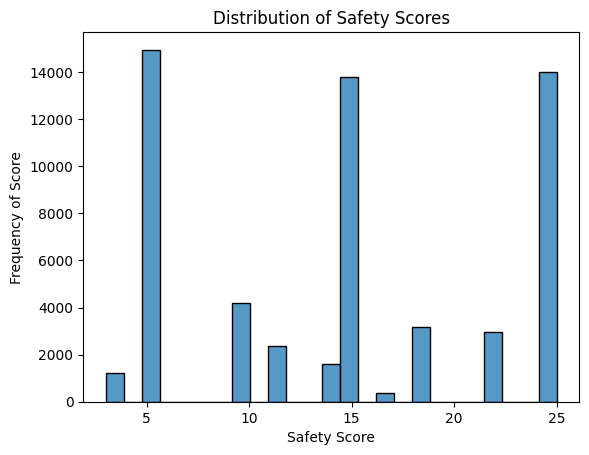

In [22]:
df["safety_score"] = df[safety_features].sum(axis=1)

sns.histplot(df["safety_score"], bins = 25)

plt.title("Distribution of Safety Scores")
plt.xlabel("Safety Score")
plt.ylabel("Frequency of Score")

# (Waskom, 2024)

To display the saftey score distribution, a histogram has been utilised. This histogram displays the distribution, and... (). The graph displays an uneven distribution which is usually problematic as it impacts the analysis, however, in this instance, it is less of a risk. The cars within th

### Box Plot

The below boxplot compares the distribution between a policyholder's claim status and their vehicle's safety score. The results will vsialusie whether the data entry of policyholders with a claim have fewer saftey features or not.

The **is_claim** column contains only two categories, making the box plot the ideal method as it provides easy analysus for the range of values, the median and also highlights any outliers **(REF)**.

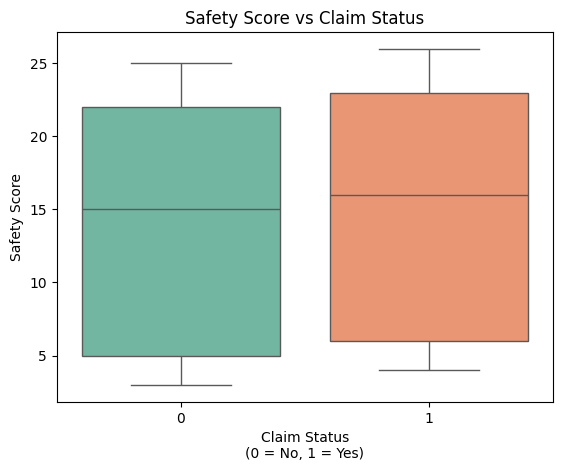

In [ ]:
sns.boxplot(x = "is_claim", y = "safety_score", data = df, palette = "Set2",
            hue = "is_claim", legend = False)

# Box Plot styles and display command
plt.title("Safety Score vs Claim Status")
plt.xlabel("Claim Status\n(0 = No, 1 = Yes)")
plt.ylabel("Safety Score")
plt.show()

# REF

The result of the boxplot above do not show any outliers which means all data is within the expected range. However, data for both claim scenraios, true and false, show to have a similar range of saftey scores, with the median for the true claim status to be slightly higher.

The visualisation does not show any clear contrast between the two claim statuses, suggesting that there may be no clear relation between the saftey score and claim status.

### Line Plot

The second method, line plot, provides a visualisation of the any trends and paterns over intervals **(REF)**. Within this situation, the method provides the opportunity to compare how the Safety Score reacts to an increase NCAP rating.

**NCAP ratings** are ratings, regionally accepted, assessing crash protection, driver-assistance technology and pedestrian safety. 0 is the lowest score, lacking modern saftey technology, and 5 is the highest, meaning it is excellent in crash protection.


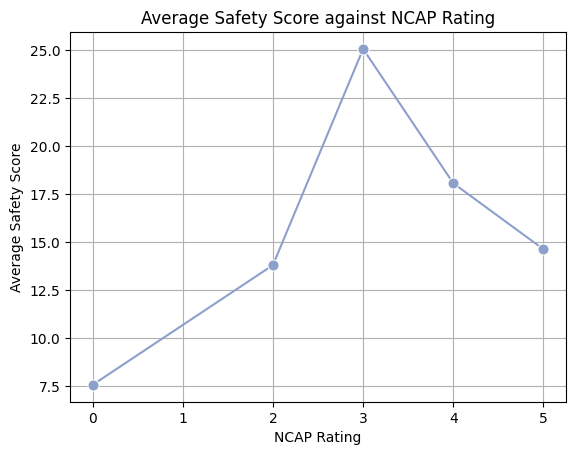

In [ ]:
# Calculates mean sfeaty scores for each NCAP Rating
mean_scores = df.groupby("ncap_rating")["safety_score"].mean()
sns.lineplot(x = mean_scores.index, y = mean_scores.values, color = "#8da0cb",
             marker = "o", markersize = 8)

# Code to style and display Line Plot
plt.title("Average Safety Score against NCAP Rating")
plt.xlabel("NCAP Rating")
plt.ylabel("Average Safety Score")
plt.grid(True) # Shows grid lines to make it easier to read
plt.show()

# W3Schools(2025)

The line plot has underscored an uneven pattern between NCAP ratings and safety scores. Vehicles with a 0 NCAP rating have the lowest average saftey score, and this score rises for a 2 rating. However, an average saftey score hits apex at a rating of 3 and then the saftey score declines at NCAP ratings 4 and 5.

There is also a missing data plot for NCAP rating 1 because it does not appear in the dataset, therefore, the line moves directly from 0 to 2.

This visualisation has shown that the average safety score does not increase alognside the NCAP rating, accentuating the suggestion that these data files do not align.

On the other hand, it is notable that as the NCAP rating increases, the average saftey score is higher than NCAP ratings 0 and 1, meaning that NCAP ratings 2 and above, generally have higher safety scores.

### Correlation Heatmap

Although correlation analysis is a method of machine learning, it is also a useful visualisation method, aiding in visualising relationships between data fields and any patterns. The colour-coded approach, makes the method easy to interpret for all readers **(REF)**, and is the final visualisation method before conducting machine learning.

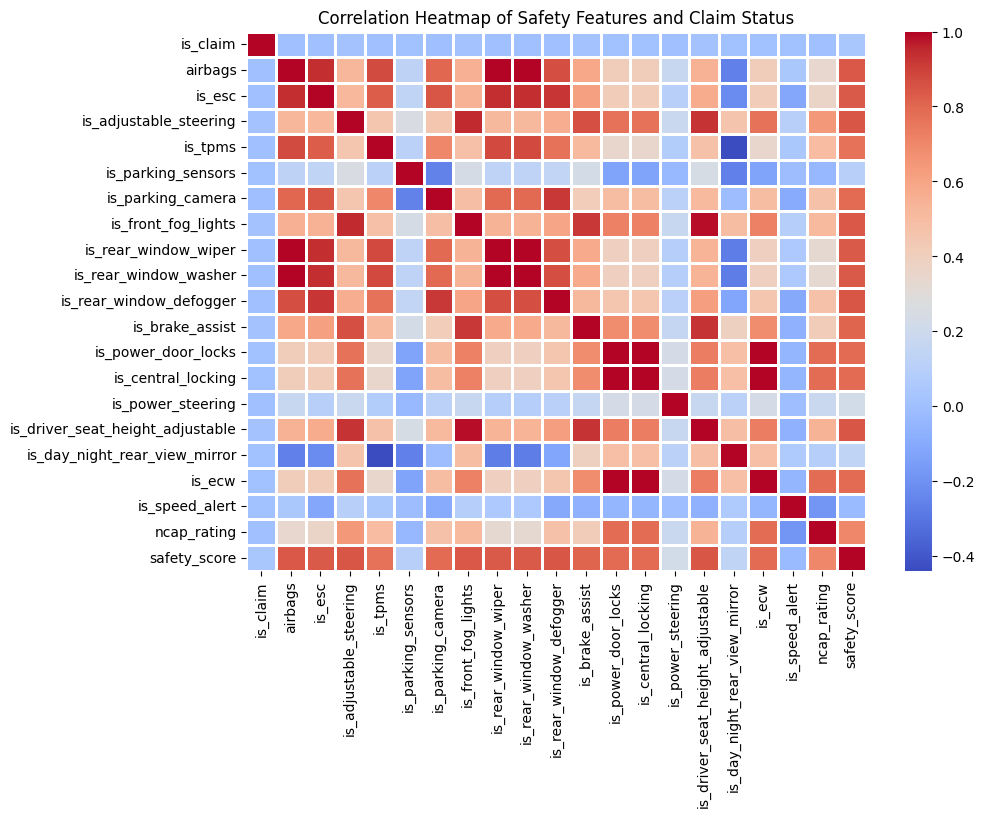

In [ ]:
# Adjusts heatmap size so it is easier to read due to the number of fields
plt.figure(figsize=(10,7))
sns.heatmap(
    df.corr(),
    cmap = "coolwarm", # Simple colour key
    linewidths = 1
)

# Styling and display command for the heatmap
plt.title("Correlation Heatmap of Safety Features and Claim Status")
plt.show()

# REF

The heatmap uses the 'coolwarm' colour scheme to help visualise the relationship between two fields- it is a highly used colour scheme, making it recognisable for readers and, therefore, easy to understand **(REF)**.

The heatmap does show some strong relationships between specific safety features, like the driver's seat being adjustable and the steering wheel, as they are directly aligned in some vehicle stylings.

But it does indicate that all saftey feature fields have a week relationship with the is_claim field, meaning that there is no clear linear relationship between them and the liklihood of a claim.

# Machine Learning

The visualisations have shown that there is a very weak or no linear relationship between the safety features in a vehicle and the liklihood of a claim. However, to further explore the research queston, the data will be passed through a machine learning model to see if the safety features can predict the liklihood of a claim, or not. The results will either corroborate or disprove the findings from the visualisations to help from an answer to the research question.

Logistic regression is primarily used for binary classification, and is a widely adopted and popular method of machine learning **(REF)**. This method is ideal in this situiation because is_claim is binary- 1 is yes and 0 and is no.



Accuracy: 0.41
Precision: 0.06
Recall: 0.61


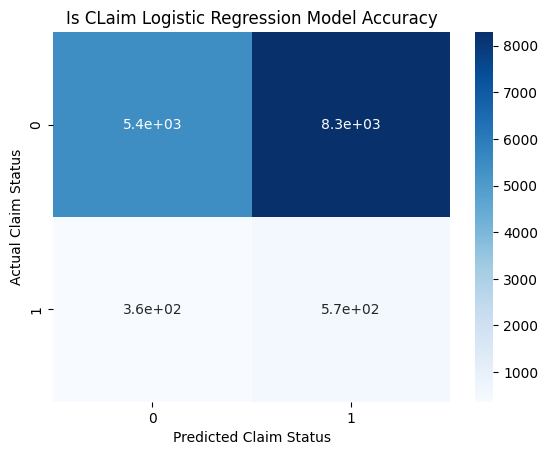

In [ ]:
# X is the data used to help predict is_claim
X = df[safety_features]
# y is the actual results which will help assess the model's accuracy
y = df["is_claim"]

# Sets the testing and training data for the regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state = 29,
                                                    stratify=y)

# Using the balanced class weight due to a lot of datasets having no claim
model = LogisticRegression(max_iter = 1000,  class_weight = "balanced")
model.fit(X_train, y_train)

# Variable to save the predicted is_claim result for trained data
y_pred = model.predict(X_test)

# Displays accuracy, precision and number of correct results (recall)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {round(accuracy,2)}")

precision = precision_score(y_test, y_pred)
print(f"Precision: {round(precision, 2)}")

recall = recall_score(y_test, y_pred)
print(f"Recall: {round(recall,2)}")
# (Gupta, 2026)

# Matrix to display the accuracy of the logistic regresion model
predictions_data = confusion_matrix(y_test, y_pred)
sns.heatmap(predictions_data, annot = True, cmap = "Blues")
plt.title("Is CLaim Logistic Regression Model Accuracy")
plt.xlabel("Predicted Claim Status")
plt.ylabel("Actual Claim Status")
plt.show()


**TALK ABOUT IT**


The model has produced a significantly low accuracy score of 0.41, with a precision rate of 0.06- meaning that 74% of the results were incorrect. Although the recall score was higher at 0.61, the heatmap has highlighted that many false positives were recorded which increased this value.

The heatmap reported that:

*   3600 predicted no claims were actual claims
*   54000 predicted no claims were correct
*   5700 preditced claims were correct
*   



Caused a lot of false positives

# Refelection

* Discuss how the findings from the data can inform business intelligence.
* Reflect on the ethical considerations related to the data handling, analysis, and visualisation process.


include hsitogram to show distributin of sfety scores to explain why different data could be used also mention the fact the data was abnormal as there were no null values and no outliers or dulicates

finish explaination of safety score

add link to kaggle claim data source?


# References

Gupta, M. (2026) Logistic regression using python, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/ml-logistic-regression-using-python/ (Accessed: 24 March 2026).

W3schools.com (2025) W3Schools Online Web Tutorials. Available at: https://www.w3schools.com/python/matplotlib_plotting.asp (Accessed: 24 March 2026).

Çetin, V. and Yıldız, O., 2022. A comprehensive review on data preprocessing techniques in data analysis. Pamukkale Üniversitesi Mühendislik Bilimleri Dergisi, 28(2), pp.299-312.

Albahra, S., Gorbett, T., Robertson, S., D'Aleo, G., Kumar, S.V.S., Ockunzzi, S., Lallo, D., Hu, B. and Rashidi, H.H., 2023, March. Artificial intelligence and machine learning overview in pathology & laboratory medicine: A general review of data preprocessing and basic supervised concepts. In Seminars in Diagnostic Pathology (Vol. 40, No. 2, pp. 71-87). WB Saunders.

Maharana, K., Mondal, S. and Nemade, B., 2022. A review: Data pre-processing and data augmentation techniques. Global Transitions Proceedings, 3(1), pp.91-99.

Yasodha, P., 2025. Data preprocessing methods for machine learning: An empirical comparison. Int. J. Multidiscip. Res, 7(3), pp.1-7.

Gordon, B., Fennessy, C., Varma, S., Barrett, J., McCondochie, E., Heritage, T., Duroe, O., Jeffery, R., Rajamani, V., Earlam, K. and Banda, V., 2022. Evaluation of freely available data profiling tools for health data research application: a functional evaluation review. BMJ open, 12(5), p.e054186.

Manovich, L., 2025. What is visualization?.

Nauman, F. and Herschel, M., 2022. An introduction to duplicate detection. Springer Nature.

Products and services (2018) Aviva. Available at: https://www.aviva.co.uk/services/about-our-business/products-and-services/ (Accessed: 28 March 2026).

Hollmann, N., Müller, S. and Hutter, F., 2023. Large language models for automated data science: Introducing caafe for context-aware automated feature engineering. Advances in Neural Information Processing Systems, 36, pp.44753-44775.

Mishra, V.K., Sebastian, S., Iqbal, M. and Anand, Y., 2023. Dealing with missing values in a relation dataset using the DROPNA function in python. Mathematics and Computer Science Volume 1, pp.463-470.

Toussaint, E., Guagliardo, P., Libkin, L. and Sequeda, J., 2022. Troubles with nulls, views from the users. Proceedings of the VLDB Endowment (PVLDB), 15(11).

Rangineni, S., Bhanushali, A., Suryadevara, M., Venkata, S. and Peddireddy, K., 2023. A Review on enhancing data quality for optimal data analytics performance. International Journal of Computer Sciences and Engineering, 11(10), pp.51-58.

Ekbote, N., Dhanshetti, P. and Sakhrekar, S., 2023. Techniques of exploratory data analysis. Madhya Pradesh Journal of Social Sciences, 28(2), pp.10-14.

Waskom, M. (2024) Seaborn.histplot#, seaborn.histplot - seaborn 0.13.2 documentation. Available at: https://seaborn.pydata.org/generated/seaborn.histplot.html (Accessed: 28 March 2026).

ENACHE, M.C., 2023. Data Analysis in e-Commerce. Economics and Applied Informatics Journal, (1), pp.1584-0409.

